# Distribution of measures

## 0. Set up

### 0.1 Import statements

In [52]:
import cmocean
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import dask
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates

from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw
import json 
from IPython.utils import io
from os.path import exists
from scipy.stats import gaussian_kde
import seaborn as sns
from itertools import chain


# MLD

In [143]:
import json

filename = '/glade/derecho/scratch/cassiacai/mhwp2_time_mean_mld_combined_vert_ens_0_100.json'
# filename = '/glade/derecho/scratch/cassiacai/mhwp2_max_mld_combined_vert_ens_0_100.json'

with open(filename, 'r') as f:
    data = json.load(f)

max_values = [max(sublist)/100 for sublist in data]

# Max MLD for Blob in FOSI is 85.9
df = pd.DataFrame({
    'Max. MLD': max_values, # Mean MLD for Blob in FOSI is 
})

In [144]:
max_values = [max(sublist)/100 for sublist in data]


In [145]:
# Max MLD for Blob in FOSI is 85.9
df = pd.DataFrame({
    'Max. MLD': max_values, # Mean MLD for Blob in FOSI is 
})

96.00% of data exceeds 85.9


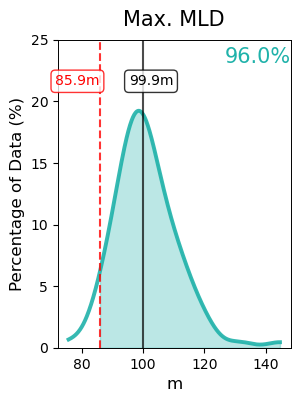

In [154]:
column_name = 'Max. MLD'
threshold = 85.9
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100
plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='red', linestyle='dashed', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='k', linestyle='-', lw=1.5, alpha=0.7)

plt.text(threshold, plt.ylim()[1]+2, 
         f'{threshold:.1f}m', 
         ha='right', 
         va='top', fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(median+10, plt.ylim()[1]+2, 
         f'{median:.1f}m', 
         ha='right', 
         va='top', fontsize=10, c='k',
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1], plt.ylim()[1]+4.25, 
         '96.0%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title(f'{column_name}', fontsize=15, pad=10)
plt.xlabel('m', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

In [56]:
num_ensembles = 100

all_mld = []
for ens_idx in range(num_ensembles):

    mld_file = f'/glade/derecho/scratch/cassiacai/mhwp2_mld_combined_vert_ens{ens_idx}.npy'
    mld_data = np.load(mld_file)
    all_mld.append(mld_data)

all_mld_stacked = np.vstack(all_mld)

In [57]:
mean_mld_lens = all_mld_stacked[:, all_mld_stacked.shape[1]//2]

In [58]:
mean_mld_lens = mean_mld_lens[~np.isnan(mean_mld_lens)]

In [67]:
# Max MLD for Blob in FOSI is 85.9
df = pd.DataFrame({
    'Mean MLD': mean_mld_lens, # Mean MLD for Blob in FOSI is 
})

62.07% of data exceeds 51.2


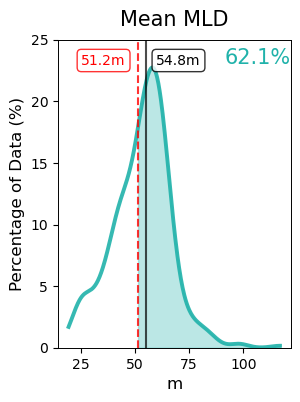

In [68]:
column_name = 'Mean MLD'
threshold = 51.2
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100
plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='red', linestyle='dashed', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='k', linestyle='-', lw=1.5, alpha=0.7)

plt.text(threshold-5.5, plt.ylim()[1], 
         f'{threshold:.1f}m', 
         ha='right', 
         va='top', fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(median+25.5, plt.ylim()[1], 
         f'{median:.1f}m', 
         ha='right', 
         va='top', fontsize=10, c='k',
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1], plt.ylim()[1]+0.5, 
         '62.1%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title(f'{column_name}', fontsize=15, pad=10)
plt.xlabel('m', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

# Duration

In [5]:
filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()

filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_ssta.nc' for i in range(100)]
da_ssta = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member').__xarray_dataarray_variable__

file_path = 'object_id_ls_greenmask_linearr2.json'
with open(file_path, 'r') as file:
    linr2_data = json.load(file)

In [83]:
all_duration_ls = []
all_mean_ssta_ls = []
all_max_ssta_ls = []

for ens_memb_index in range(0, 100):
    print(ens_memb_index)

    duration_ls = []
    mean_ssta_ls = []
    max_ssta_ls = []
    for mhw_ind in range(len(linr2_data[4][ens_memb_index])):
        mhw_ind_obj_id = linr2_data[4][ens_memb_index][mhw_ind]
    
        # get the MHW event
        blobs = da_mhwobj_labels.isel(ensemble_member = ens_memb_index)
        object_count_per_time = (blobs == mhw_ind_obj_id).sum(dim=['lat', 'lon'])
        true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)

        one_obj = blobs.sel(time=true_time_steps.time)
        blobs_nan = xr.where(one_obj == mhw_ind_obj_id, 1., 0.)
        one_obj_ssta = blobs_nan * da_ssta.isel(ensemble_member = ens_memb_index).compute()
        one_obj_ssta_nan = xr.where(one_obj_ssta == 0., np.nan, one_obj_ssta)

        # mean_ssta = list(one_obj_ssta_nan.mean(dim=('lat','lon')).data)
        # max_ssta = list(one_obj_ssta_nan.max(dim=('lat','lon')).data)

        mean_ssta = one_obj_ssta_nan.mean().item()
        max_ssta = one_obj_ssta_nan.max().item()
        duration_ls.append(len(true_time_steps))
        mean_ssta_ls.append(mean_ssta)
        max_ssta_ls.append(max_ssta)

    all_duration_ls.append(duration_ls)
    all_mean_ssta_ls.append(mean_ssta_ls)
    all_max_ssta_ls.append(max_ssta_ls)

# filename = '/glade/derecho/scratch/cassiacai/mhwp2_duration_compare_ens_0_100.json'
# with open(filename, 'w') as f:
#     json.dump(all_duration_ls, f)

# filename = '/glade/derecho/scratch/cassiacai/mhwp2_mean_ssta_ens_0_100.json'
# with open(filename, 'w') as f:
#     json.dump(all_mean_ssta_ls, f)

# filename = '/glade/derecho/scratch/cassiacai/mhwp2_max_ssta_ens_0_100.json'
# with open(filename, 'w') as f:
#     json.dump(all_max_ssta_ls, f)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [70]:
df = pd.DataFrame({
    'Duration': list(chain.from_iterable(all_duration_ls)), # Duration for the Blob is 20
})

13.51% of data exceeds 20


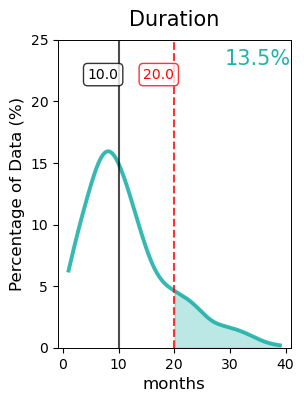

In [77]:
column_name = 'Duration'
threshold = 20
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100
plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='red', linestyle='dashed', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='k', linestyle='-', lw=1.5, alpha=0.7)

plt.text(threshold, plt.ylim()[1]+6, 
         f'{threshold:.1f}', 
         ha='right', 
         va='top', fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(median, plt.ylim()[1]+6, 
         f'{median:.1f}', 
         ha='right', 
         va='top', fontsize=10, c='k',
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1], plt.ylim()[1]+7.5, 
         '13.5%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title(f'{column_name}', fontsize=15, pad=10)
plt.xlabel('months', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

In [99]:
df = pd.DataFrame({
    'Mean SSTa': list(chain.from_iterable(all_mean_ssta_ls)), # Duration for the Blob is 20
    'Max. SSTa': list(chain.from_iterable(all_max_ssta_ls)), # Duration for the Blob is 20
})

87.22% of data exceeds 1.1


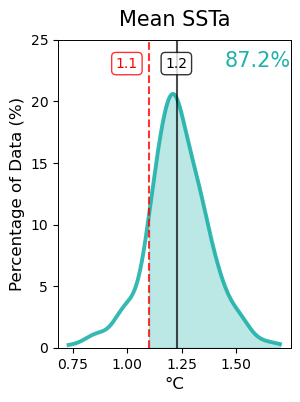

In [130]:
column_name = 'Mean SSTa'
threshold = 1.1#2.4#1.017#2.35 #1.1 is the mean
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100
plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='red', linestyle='dashed', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='k', linestyle='-', lw=1.5, alpha=0.7)

plt.text(threshold-0.05, plt.ylim()[1]+2, 
         f'{threshold:.1f}', 
         ha='right', 
         va='top', fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(median+0.05, plt.ylim()[1]+2, 
         f'{median:.1f}', 
         ha='right', 
         va='top', fontsize=10, c='k',
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1], plt.ylim()[1]+2.5, 
         '87.2%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title(f'{column_name}', fontsize=15, pad=10)
plt.xlabel('°C', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

# PDO

# Nino 3.4

## 1. Loading data

In [2]:
filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_ssta_notrend.nc' for i in range(100)]
da_ssta = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.compute()

mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj

In [3]:
#### MEASURES using R = 3
base_path = '/glade/u/home/cmendiola/mhw_project/'

accelerations = json.load(open(f'{base_path}accelerations.json'))
centroid = json.load(open(f'{base_path}centroid.json'))
complement_to_deformation = json.load(open(f'{base_path}complement_to_deformation.json'))
convex_hull_areas = json.load(open(f'{base_path}convex_hull_areas.json'))
deformation = json.load(open(f'{base_path}deformation.json'))
displacements_of_centroids = json.load(open(f'{base_path}displacements.json'))
perimeter = json.load(open(f'{base_path}perimeter.json'))
ratio_convexhullarea_vs_area = json.load(open(f'{base_path}ratio_convexhullarea_vs_area.json'))
spatial_extent = json.load(open(f'{base_path}spatial_extent.json'))
velocities = json.load(open(f'{base_path}velocities.json'))
durations = np.load('/glade/u/home/cassiacai/measures/duration_all.npy')

percentile_per_timestep = json.load(open(f'{base_path}90th Percentile Per Timestep.json'))
percentile_90th = json.load(open(f'{base_path}90th Percentile.json'))
max_ssta = json.load(open(f'{base_path}Max SSTA.json'))
mean_ssta = json.load(open(f'{base_path}Mean SSTA.json'))
std_per_timestep = json.load(open(f'{base_path}Standard Deviation per Timestep.json'))
std_dev = json.load(open(f'{base_path}Standard Deviation.json'))
integrated_intensity = json.load(open(f'{base_path}Integrated Intensity.json'))

In [7]:
blob_like_ids = json.load(open('object_id_ls_greenmask.json'))

In [5]:
# The Blob in FOSI's measures
Blob_FOSI_spatial_extents = [
    4,954,528.04,  # Month 1
    8,136,385.88,  # Month 2
    13,613,680.49, # Month 3
    15,327,926.93, # Month 4
    13,172,350.02, # Month 5
    9,981,505.92,  # Month 6
    15,911,072.18, # Month 7
    18,376,923.80, # Month 8
    19,481,820.35, # Month 9
    20,474,938.72, # Month 10 (max)
    15,960,064.46, # Month 11
    14,466,890.30  # Month 12
]

Blob_FOSI_spatial_extent_stats = {
    'max_value': 20474938.72,
    'max_month': 9,  # 0-based index (Month 10)
    'mean_value': 14154840.59,
    'cumulative_total': 169858087.08
}

Blob_FOSI_fosi_perimeters = [
    16,619.84, 23,020.83, 32,895.37, 33,711.22,
    31,834.44, 31,890.63, 32,057.01, 25,310.87,
    29,229.02, 32,696.20, 26,968.73, 23,280.68
]

Blob_FOSI_fosi_deformation = {
    'complement': [0.369, 0.357, 0.467, 0.442, 0.381, 
                  0.365, 0.418, 0.455, 0.416, 0.396, 0.459],
    'deformation': [0.631, 0.643, 0.533, 0.558, 0.619,
                   0.635, 0.582, 0.545, 0.584, 0.604, 0.541]
}

Blob_FOSI_convex_hull_areas = [
    8,794,215.79, 14,442,574.63, 19,620,913.01,
    23,316,885.65, 19,402,571.05, 20,706,202.17,
    33,999,381.91, 22,994,884.19, 26,371,107.25,
    31,579,067.93, 23,891,757.27, 19,902,900.87
]

Blob_FOSI_centroid_data = {
    'initial_position': (39.11, 227.5),
    'monthly_positions': [
        (36.09, 62.45), (32.16, 59.49), (24.01, 59.26),
        (24.70, 58.16), (20.29, 60.66), (23.08, 61.81),
        (21.61, 56.88), (18.52, 55.66), (18.54, 54.06),
        (18.24, 48.56), (15.44, 57.36), (15.37, 59.28)
    ],
    'displacement_distances': [
        609.33, 840.85, 200.86, 628.29, 350.50,
        866.24, 383.11, 284.01, 980.07, 1607.37, 347.98
    ],
    'smoothed_positions': [
        (35.34, 223.75), (27.80, 223.75), (28.74, 222.5),
        (24.03, 226.25), (26.86, 227.5), (25.92, 221.25),
        (23.09, 220.0), (23.09, 217.5), (22.15, 211.25),
        (19.32, 221.25), (19.32, 223.75)
    ]
}

Blob_FOSI_movement_metrics = {
    'velocity': [  # (x_velocity, y_velocity)
        (-3.77, -3.75), (-7.54, 0.0), (0.94, -1.25),
        (-4.71, 3.75), (2.83, 1.25), (-0.94, -6.25),
        (-2.83, -1.25), (0.0, -2.5), (-0.94, -6.25),
        (-2.83, 10.0), (0.0, 2.5)
    ],
    'acceleration': [  # (x_accel, y_accel)
        (-3.77, 3.75), (8.48, -1.25), (-5.65, 5.0),
        (7.54, -2.5), (-3.77, -7.5), (-1.88, 5.0),
        (2.83, -1.25), (-0.94, -3.75), (-1.88, 16.25),
        (2.83, -7.5)
    ]
}

In [6]:
all_unique_labels_ls = []
no_items = []
for ensemble_member_id in range(100):
    blob_labels = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
    unique_labels = np.unique(blob_labels.max(dim=('lat','lon')).data)[:-1]
    all_unique_labels_ls.append(unique_labels)
    no_items.append(len(unique_labels))

In [7]:
blob_analog_mean_max_vals_ls = []
blob_analog_mean_mean_vals_ls = []

for ens_memb in range(100):
    indices = blob_like_ids[4][ens_memb]
    
    indices_of_blob_analogs = []
    for val in indices:
        matches = np.where(all_unique_labels_ls[ens_memb] == val)[0]
        if matches.size > 0:  # Only proceed if the value exists
            indices_of_blob_analogs.append(matches[0])
    
    # If no matches, skip this iteration (or handle differently)
    if not indices_of_blob_analogs:
        print(f"No matches found for ens_memb {ens_memb}, skipping...")
        continue  # Skip this iteration
    
    mean_max_values = [max(sublist) for sublist in max_ssta[ens_memb]]
    mean_max_values_array = np.asarray(mean_max_values)
    blob_analog_mean_max_vals = mean_max_values_array[indices_of_blob_analogs]
    blob_analog_mean_max_vals_ls.append(blob_analog_mean_max_vals)

    mean_mean_values = [max(sublist) for sublist in mean_ssta[ens_memb]]
    mean_mean_values_array = np.asarray(mean_mean_values)
    blob_analog_mean_mean_vals = mean_mean_values_array[indices_of_blob_analogs]
    blob_analog_mean_mean_vals_ls.append(blob_analog_mean_mean_vals)


In [161]:
len(mean_max_ssta)

424

In [8]:
mean_max_ssta = np.concatenate(blob_analog_mean_max_vals_ls).ravel().tolist()
mean_mean_ssta = np.concatenate(blob_analog_mean_mean_vals_ls).ravel().tolist()

In [9]:
df = pd.DataFrame({
    'Max SSTa': mean_max_ssta,
    'Mean SSTa': mean_mean_ssta,
})

In [10]:
# Initialize empty lists for each variable
blob_analog_mean_max_vals_ls = []
blob_analog_mean_mean_vals_ls = []
blob_analog_90th_percentile_vals_ls = []
blob_analog_90th_percentile_timestep_vals_ls = []
blob_analog_std_dev_vals_ls = []
blob_analog_std_dev_timestep_vals_ls = []
blob_analog_integrated_intensity_vals_ls = []

blob_analog_mean_spatial_extent_ls = []
blob_analog_max_spatial_extent_ls = []
blob_analog_max_displacement_ls = []
blob_analog_mean_displacement_ls = []

for ens_memb in range(100):
    indices = blob_like_ids[4][ens_memb]
    
    # Get valid indices for blob analogs
    indices_of_blob_analogs = []
    for val in indices:
        matches = np.where(all_unique_labels_ls[ens_memb] == val)[0]
        if matches.size > 0:
            indices_of_blob_analogs.append(matches[0])
    
    if not indices_of_blob_analogs:
        print(f"No matches found for ens_memb {ens_memb}, skipping...")
        continue
    
    # Process MAX SSTA
    mean_max_values = [max(sublist) for sublist in max_ssta[ens_memb]]
    mean_max_values_array = np.asarray(mean_max_values)
    blob_analog_mean_max_vals_ls.append(mean_max_values_array[indices_of_blob_analogs])
    
    # Process MEAN SSTA
    mean_mean_values = [max(sublist) for sublist in mean_ssta[ens_memb]]
    mean_mean_values_array = np.asarray(mean_mean_values)
    blob_analog_mean_mean_vals_ls.append(mean_mean_values_array[indices_of_blob_analogs])
    
    # Process 90th Percentile
    percentile_values = [max(sublist) for sublist in percentile_90th[ens_memb]]
    percentile_values_array = np.asarray(percentile_values)
    blob_analog_90th_percentile_vals_ls.append(percentile_values_array[indices_of_blob_analogs])
    
    # Process 90th Percentile Per Timestep
    percentile_timestep_values = [max(sublist) for sublist in percentile_per_timestep[ens_memb]]
    percentile_timestep_array = np.asarray(percentile_timestep_values)
    blob_analog_90th_percentile_timestep_vals_ls.append(percentile_timestep_array[indices_of_blob_analogs])
    
    # Process Standard Deviation
    # std_dev_values = [max(sublist) for sublist in std_dev[ens_memb]]
    # std_dev_array = np.asarray(std_dev_values)
    # blob_analog_std_dev_vals_ls.append(std_dev_array[indices_of_blob_analogs])
    
    # Process Standard Deviation per Timestep
    std_dev_timestep_values = [max(sublist) for sublist in std_per_timestep[ens_memb]]
    std_dev_timestep_array = np.asarray(std_dev_timestep_values)
    blob_analog_std_dev_timestep_vals_ls.append(std_dev_timestep_array[indices_of_blob_analogs])
    
    # Process Integrated Intensity
    int_intensity_values = [max(sublist) for sublist in integrated_intensity[ens_memb]]
    int_intensity_array = np.asarray(int_intensity_values)
    blob_analog_integrated_intensity_vals_ls.append(int_intensity_array[indices_of_blob_analogs])

    # Spatial Extent (mean and max)
    spatial_extent_values = [max(sublist) for sublist in spatial_extent[ens_memb]]
    spatial_extent_array = np.asarray(spatial_extent_values)
    blob_analog_max_spatial_extent_ls.append(spatial_extent_array[indices_of_blob_analogs])

    spatial_extent_values = [np.mean(sublist) for sublist in spatial_extent[ens_memb]]
    spatial_extent_array = np.asarray(spatial_extent_values)
    blob_analog_mean_spatial_extent_ls.append(spatial_extent_array[indices_of_blob_analogs])
    
# Optional: Convert lists to numpy arrays for easier analysis
blob_analog_mean_max_vals_array = np.concatenate(blob_analog_mean_max_vals_ls)
blob_analog_mean_mean_vals_array = np.concatenate(blob_analog_mean_mean_vals_ls)
# blob_analog_90th_percentile_array = np.concatenate(blob_analog_90th_percentile_vals_ls)
blob_analog_90th_percentile_timestep_array = np.concatenate(blob_analog_90th_percentile_timestep_vals_ls)
# blob_analog_std_dev_array = np.concatenate(blob_analog_std_dev_vals_ls)
blob_analog_std_dev_timestep_array = np.concatenate(blob_analog_std_dev_timestep_vals_ls)
blob_analog_integrated_intensity_array = np.concatenate(blob_analog_integrated_intensity_vals_ls)
blob_analog_max_spatial_extent_array = np.concatenate(blob_analog_max_spatial_extent_ls)
blob_analog_mean_spatial_extent_array = np.concatenate(blob_analog_mean_spatial_extent_ls)

In [165]:
len(std_dev_timestep_values)

99

In [109]:
displacement_values_new = [sublist for sublist in displacements_of_centroids[ens_memb]]


In [111]:
len(displacement_values_new)

98

In [169]:
displacement_values_newnew_ls = []

for ens_memb in range(100):
    displacement_values_new = [sublist for sublist in displacements_of_centroids[ens_memb]]
    # std_dev_timestep_values = [sublist for sublist in displacements_of_centroids[ens_memb]]
    for i in range(len(displacement_values_new)):
        displacement_values_newnew = [np.mean(sublist) for sublist in displacement_values_new[i]][1]
        print(displacement_values_newnew)
        displacement_values_newnew_ls.append(displacement_values_newnew)

768.4080378115376
38.4445040179061
937.1289494982092
1379.3703723074273
1643.3652118228993
nan
nan
nan
nan
1516.3203731763122
nan
nan
967.9707492702862
1483.5710069850893
nan
nan
nan
nan
779.0609701852646
nan
843.2420597664566
787.6414142207772
nan
2441.365821311349
nan
nan
917.2643233427601
nan
627.9186212431961
515.3516908969365
nan
646.8898684900358
nan
nan
772.361170592962
4105.623010105509
853.0089955479715
nan
2071.7844217930915
nan
713.3550874987873
nan
1037.1103794838677
nan
nan
122.851872525315
742.9341882989901
1327.92604625731
520.4262432468893
nan
1572.7869130485776
111.40681342285583
1223.2501448582127
nan
1096.337345051679
1372.4116731082509
888.6090792934841
nan
758.4042282322365
nan
nan
625.6473727100016
nan
544.8118416574788
688.8045299446756
nan
nan
nan
1989.2607238329633
nan
526.8040406431718
1084.1194459489866
nan
934.9963449081621
nan
1222.584670353154
3675.541145809855
2375.3836364056515
nan
nan
1375.8562137042181
770.3758471650665
nan
1102.591256182917
2356.46571

In [167]:
len(displacement_values_newnew_ls)

9900

In [164]:
len(displacement_values_new)

99

In [157]:
len(displacement_values_newnew_ls)

9359

In [11]:
len(durations)

9359

In [12]:
# First create a combined DataFrame with all variables
df = pd.DataFrame({
    'Max SSTA': blob_analog_mean_max_vals_array,
    'Mean SSTA': blob_analog_mean_mean_vals_array,
    '90th Perc': blob_analog_90th_percentile_timestep_array,
    'Std Dev': blob_analog_std_dev_timestep_array,
    'C Intensity': blob_analog_integrated_intensity_array,
    'Mean Spatial Extent': blob_analog_mean_spatial_extent_array,
    'Max Spatial Extent': blob_analog_max_spatial_extent_array,
    # 'Duration': durations,
    
}).dropna()

In [13]:
ens_memb = 0

In [14]:
indices = blob_like_ids[4][ens_memb]

In [15]:
indices_of_blob_analogs = [np.where(all_unique_labels_ls[ens_memb] == val)[0][0] for val in indices]

In [16]:
max_values = [max(sublist) for sublist in max_ssta[ens_memb]]
max_values_array = np.asarray(max_values)
blob_analog_vals = max_values_array[indices_of_blob_analogs]

In [17]:
blob_analog_vals = max_values_array[indices_of_blob_analogs]

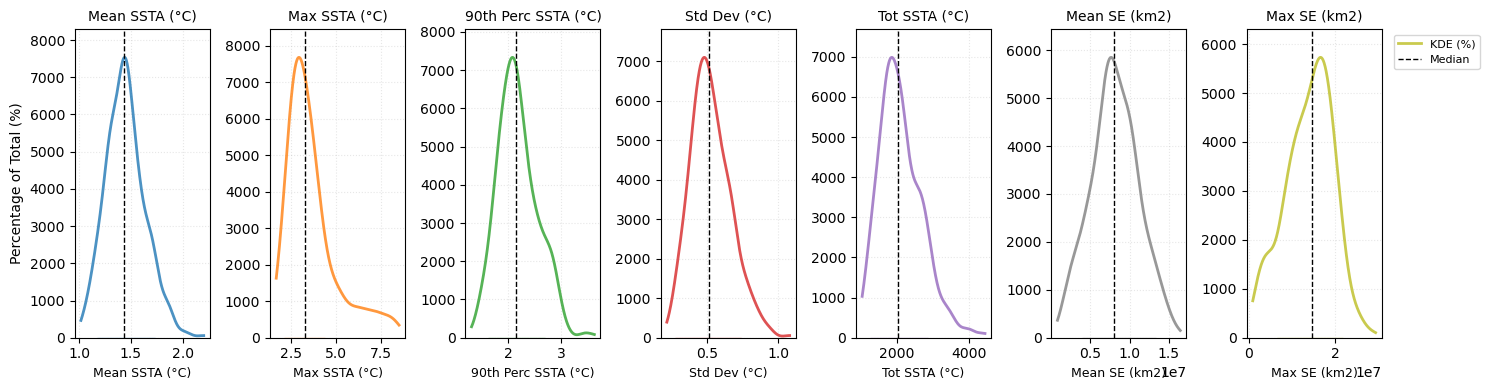

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde

# Create DataFrame
df = pd.DataFrame({
    'Mean SSTA (°C)': blob_analog_mean_mean_vals_array,
    'Max SSTA (°C)': blob_analog_mean_max_vals_array,
    '90th Perc SSTA (°C)': blob_analog_90th_percentile_timestep_array,
    'Std Dev (°C)': blob_analog_std_dev_timestep_array,
    'Tot SSTA (°C)': blob_analog_integrated_intensity_array,
    'Mean SE (km2)': blob_analog_mean_spatial_extent_array,
    'Max SE (km2)': blob_analog_max_spatial_extent_array,
}).dropna()

# Set up plot
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
           '#9467bd', '#7f7f7f', '#bcbd22']

# Create subplots
fig, axes = plt.subplots(1, len(df.columns), figsize=(15, 4), sharey=False)

for ax, (var, color) in zip(axes, zip(df.columns, palette)):
    # --- Histogram (Percentage of Total Counts) ---
    counts, bins, _ = ax.hist(
        df[var],
        bins=15,                     # Adjust bin count
        color=color,
        alpha=0.3,
        density=False,              # We want raw counts
        edgecolor='white',
        weights=np.ones_like(df[var]) / len(df[var]) * 100  # Convert to %
    )
    
    # --- KDE (Scaled to Percentage of Total) ---
    kde = gaussian_kde(df[var])
    x = np.linspace(df[var].min(), df[var].max(), 500)
    y = kde(x) * (bins[1] - bins[0]) * len(df[var]) * 100  # Scale to % of total
    
    ax.plot(x, y, color=color, linewidth=2, alpha=0.8, label='KDE (%)')
    
    # --- Median Line ---
    median = np.median(df[var])
    ax.axvline(median, color='black', linestyle='--', linewidth=1, label='Median')
    
    # --- Formatting ---
    ax.set_title(var, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.3)
    ax.set_ylim(0, max(np.max(counts), np.max(y)) * 1.1)  # 10% padding
    
    if ax == axes[0]:
        ax.set_ylabel('Percentage of Total (%)', fontsize=10)
    ax.set_xlabel(var, fontsize=9)

# Add legend to the last subplot (optional)
axes[-1].legend(fontsize=8, bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

<Figure size 1200x300 with 0 Axes>

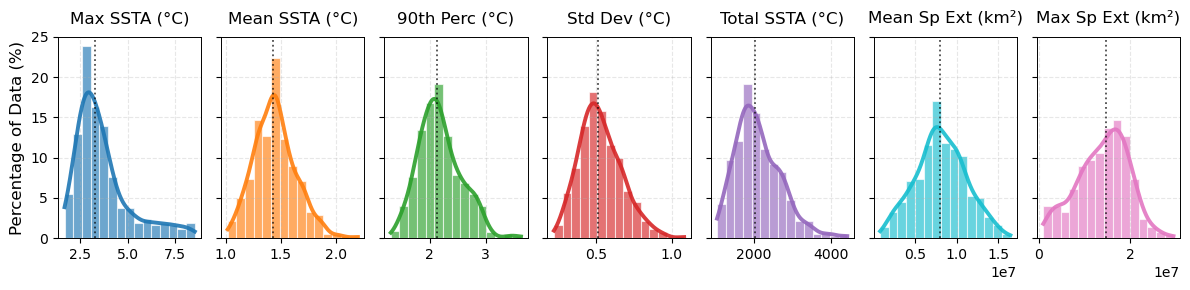

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import gaussian_kde

# Create DataFrame
df = pd.DataFrame({
    'Max SSTA (°C)': blob_analog_mean_max_vals_array,
    'Mean SSTA (°C)': blob_analog_mean_mean_vals_array,
    '90th Perc (°C)': blob_analog_90th_percentile_timestep_array,
    'Std Dev (°C)': blob_analog_std_dev_timestep_array,
    'Total SSTA (°C)': blob_analog_integrated_intensity_array,
    'Mean Sp Ext (km²)': blob_analog_mean_spatial_extent_array,
    'Max Sp Ext (km²)': blob_analog_max_spatial_extent_array,
}).dropna()

# ---- Hybrid Color Palette (rainbow-inspired + muted classics) ----
hybrid_palette = [
    '#1f77b4',  # Classic blue (from your palette)
    '#ff7f0e',  # Classic orange (from your palette)
    '#2ca02c',  # Classic green (from your palette)
    '#d62728',  # Classic red (from your palette)
    '#9467bd',  # Classic purple (from your palette)
    '#17becf',  # Bright cyan (rainbow-inspired)
    '#e377c2',  # Soft pink (rainbow-inspired)
]

# Set up plot with refined styling
plt.figure(figsize=(12, 3))
fig, axes = plt.subplots(1, len(df.columns), figsize=(12, 3), sharey=True)

# Plot each variable
for ax, (var, color) in zip(axes, zip(df.columns, hybrid_palette)):
    # --- Histogram (Percentage of Data) ---
    counts, bin_edges = np.histogram(df[var], bins=15)
    bin_percentages = (counts / len(df[var])) * 100
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]
    
    # Plot bars with softer edges
    bars = ax.bar(bin_centers, bin_percentages, 
                 width=bin_width, 
                 color=color, 
                 alpha=0.65,          # Slightly more transparent
                 edgecolor='white',   # Soft edge
                 linewidth=0.8)
    
    # --- KDE (Scaled to Percentage) ---
    kde = gaussian_kde(df[var])
    x = np.linspace(df[var].min(), df[var].max(), 500)
    y_kde = kde(x) * bin_width * 100  # Scale to %
    
    # Smoother KDE line with gradient effect
    ax.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)
    
    # --- Median Line (subtle) ---
    median = np.median(df[var])
    ax.axvline(median, color='black', linestyle=':', lw=1.3, alpha=0.7)
    # ax.text(median, ax.get_ylim()[1]*0.85, f'Median: {median:.1f}', 
    #         ha='center', va='center', fontsize=9,
    #         backgroundcolor='white', alpha=0.8)
    
    # --- Formatting (matching your scatter plot style) ---
    ax.set_title(var, fontsize=12, pad=10, color='k')
    ax.set_xlabel('')
    ax.set_ylim(0, 25)
    ax.set_yticks(np.arange(0, 26, 5))
    
    # Grid and background (matching your scatter plot)
    ax.grid(True, linestyle='--', alpha=0.3)
    # ax.set_facecolor('#f8f8f8')  # Light gray background
    ax.set_facecolor('white')  # Light gray background

    
    # Axis spines (matching your scatter plot)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor('k')
        spine.set_linewidth(0.7)
    
    # Only show y-label on first plot
    if ax == axes[0]:
        ax.set_ylabel('Percentage of Data (%)', fontsize=12, color='k')


# Adjust layout
plt.tight_layout()
# plt.subplots_adjust(wspace=0.25)  # Slightly more space between subplots

plt.show()

88.92% of data exceeds 2.34995539


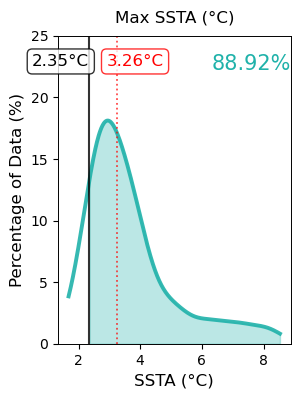

In [47]:
# Your data and threshold
column_name = 'Max SSTA (°C)'
threshold = 2.34995539
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))

# --- Histogram ---
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# bars = plt.bar(bin_centers, bin_percentages, 
#               width=bin_width, 
#               color=color, 
#               alpha=0.65,
#               edgecolor='white',
#               linewidth=0.8)

# --- KDE ---
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100

plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)

# --- Shade area ABOVE threshold (top X%) ---
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='k', linestyle='-', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='red', linestyle=':', lw=1.3, alpha=0.7)

# # --- Annotate the threshold ---
# plt.text(threshold, plt.ylim()[1], 
#          f'{threshold:.2f}°C', 
#          ha='right', va='top', backgroundcolor='whitesmoke', fontsize=12)

# --- Annotate the threshold ---
plt.text(threshold, plt.ylim()[1]+4.5, 
         f'{threshold:.2f}°C', 
         ha='right', 
         va='top', fontsize=12, 
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

# --- Annotate the threshold ---
plt.text(median+1.5, plt.ylim()[1]+4.5, 
         f'{median:.2f}°C', 
         ha='right', 
         va='top', fontsize=12, c='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1], plt.ylim()[1]+4.5, 
         '88.92%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title(f'{column_name}', fontsize=12, pad=10)
plt.xlabel('SSTA (°C)', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

99.76% of data exceeds 1.02863576


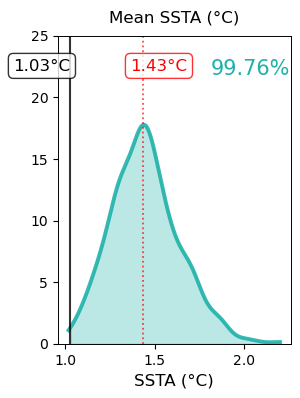

In [54]:
# Your data and threshold
column_name = 'Mean SSTA (°C)'
threshold = 1.02863576
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))

# --- Histogram ---
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# bars = plt.bar(bin_centers, bin_percentages, 
#               width=bin_width, 
#               color=color, 
#               alpha=0.65,
#               edgecolor='white',
#               linewidth=0.8)

# --- KDE ---
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100

plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)

# --- Shade area ABOVE threshold (top X%) ---
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='k', linestyle='-', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='red', linestyle=':', lw=1.3, alpha=0.7)

# # --- Annotate the threshold ---
# plt.text(threshold, plt.ylim()[1], 
#          f'{threshold:.2f}°C', 
#          ha='right', va='top', backgroundcolor='whitesmoke', fontsize=12)

# --- Annotate the threshold ---
plt.text(threshold, plt.ylim()[1]+4.5, 
         f'{threshold:.2f}°C', 
         ha='right', 
         va='top', fontsize=12, 
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

# --- Annotate the threshold ---
plt.text(median+0.25, plt.ylim()[1]+4.5, 
         f'{median:.2f}°C', 
         ha='right', 
         va='top', fontsize=12, c='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1], plt.ylim()[1]+4.5, 
         '99.76%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title(f'{column_name}', fontsize=12, pad=10)
plt.xlabel('SSTA (°C)', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12, c='white')
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

98.82% of data exceeds 1.46650888


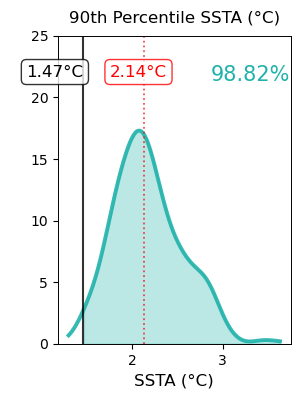

In [64]:
# Your data and threshold
column_name = '90th Perc (°C)'
threshold = 1.46650888
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))

# --- Histogram ---
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# bars = plt.bar(bin_centers, bin_percentages, 
#               width=bin_width, 
#               color=color, 
#               alpha=0.65,
#               edgecolor='white',
#               linewidth=0.8)

# --- KDE ---
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100

plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)

# --- Shade area ABOVE threshold (top X%) ---
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='k', linestyle='-', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='red', linestyle=':', lw=1.3, alpha=0.7)

# # --- Annotate the threshold ---
# plt.text(threshold, plt.ylim()[1], 
#          f'{threshold:.2f}°C', 
#          ha='right', va='top', backgroundcolor='whitesmoke', fontsize=12)

# --- Annotate the threshold ---
plt.text(threshold, plt.ylim()[1]+4.5, 
         f'{threshold:.2f}°C', 
         ha='right', 
         va='top', fontsize=12, 
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

# --- Annotate the threshold ---
plt.text(median+0.25, plt.ylim()[1]+4.5, 
         f'{median:.2f}°C', 
         ha='right', 
         va='top', fontsize=12, c='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1], plt.ylim()[1]+4.5, 
         '98.82%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title('90th Percentile SSTA (°C)', fontsize=12, pad=10)
plt.xlabel('SSTA (°C)', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12, c='white')
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

In [155]:
blob_max_spext = 20502950.863199756
blob_cumu_spext = 226285068.32525513
blob_mean_spext = 11314253.416262757

In [216]:
import json

filename = '/glade/derecho/scratch/cassiacai/mhwp2_spext_cumu_ens_0_100.json'
# filename = '/glade/derecho/scratch/cassiacai/mhwp2_spext_mean_ens_0_100.json'
# filename = '/glade/derecho/scratch/cassiacai/mhwp2_spext_max_ens_0_100.json'

with open(filename, 'r') as f:
    data = json.load(f)

# Max MLD for Blob in FOSI is 85.9
df = pd.DataFrame({
    'Total Spatial Extent': list(chain.from_iterable(data)), # Mean MLD for Blob in FOSI is 
})

10.07% of data exceeds 226285068.32525513


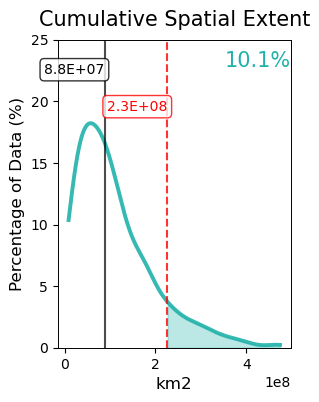

In [225]:
# Your data and threshold
column_name = 'Total Spatial Extent'
threshold = blob_cumu_spext#blob_max_spext# 20474938.722628646
# threshold = 14154840.590405503
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))

# --- Histogram ---
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# bars = plt.bar(bin_centers, bin_percentages, 
#               width=bin_width, 
#               color=color, 
#               alpha=0.65,
#               edgecolor='white',
#               linewidth=0.8)

# --- KDE ---
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100

plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)

# --- Shade area ABOVE threshold (top X%) ---
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# # --- Threshold & Median Lines ---
# plt.axvline(threshold, color='red', linestyle='dashed', lw=1.5, alpha=0.8)
# median = np.median(df[column_name])
# plt.axvline(median, color='k', linestyle='-', lw=2, alpha=0.7)

# # # --- Annotate the threshold ---
# # plt.text(threshold, plt.ylim()[1], 
# #          f'{threshold:.2f}°C', 
# #          ha='right', va='top', backgroundcolor='whitesmoke', fontsize=12)

# # --- Annotate the threshold ---
# plt.text(threshold, plt.ylim()[1]+3.5, 
#          f'{threshold:.1E}', 
#          ha='right', 
#          va='top', fontsize=10, 
#          bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

# # --- Annotate the threshold ---
# plt.text(median+0.5, plt.ylim()[1]+6.5, 
#          f'{median:.1E}', 
#          ha='right', 
#          va='top', fontsize=10, c='red',
#          bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1]+0.5, plt.ylim()[1]+5., 
         '10.1%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

plt.axvline(threshold, color='red', linestyle='dashed', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='k', linestyle='-', lw=1.5, alpha=0.7)

plt.text(threshold-15, plt.ylim()[1]+1, 
         f'{threshold:.1E}', 
         ha='right', 
         va='top', fontsize=10, color='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(median+200, plt.ylim()[1]+4, 
         f'{median:.1E}', 
         ha='right', 
         va='top', fontsize=10, c='k',
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))


# --- Styling ---
plt.title('Cumulative Spatial Extent', fontsize=15, pad=10)
plt.xlabel('km2', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12, c='k')
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

In [164]:
# Your data and threshold
column_name = 'Mean Sp Ext (km²)'
threshold = 14154840.590405503
# threshold = 14154840.590405503
color = 'lightseagreen'

# --- Calculate % beyond threshold ---
pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))

# --- Histogram ---
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# bars = plt.bar(bin_centers, bin_percentages, 
#               width=bin_width, 
#               color=color, 
#               alpha=0.65,
#               edgecolor='white',
#               linewidth=0.8)

# --- KDE ---
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100

plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)

# --- Shade area ABOVE threshold (top X%) ---
mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='k', linestyle='-', lw=1.5, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='red', linestyle='-', lw=2, alpha=0.7)

# # --- Annotate the threshold ---
# plt.text(threshold, plt.ylim()[1], 
#          f'{threshold:.2f}°C', 
#          ha='right', va='top', backgroundcolor='whitesmoke', fontsize=12)

# --- Annotate the threshold ---
plt.text(threshold, plt.ylim()[1]+3.5, 
         f'{threshold:.1E}', 
         ha='right', 
         va='top', fontsize=12, 
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

# --- Annotate the threshold ---
plt.text(median+0.5, plt.ylim()[1]+6.5, 
         f'{median:.1E}', 
         ha='right', 
         va='top', fontsize=12, c='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1]+0.5, plt.ylim()[1]+9.5, 
         '2.59%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen')

# --- Styling ---
plt.title('Mean Spatial Extent', fontsize=12, pad=10)
plt.xlabel('Spatial Extent (km2)', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12, c='white')
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

KeyError: 'Mean Sp Ext (km²)'

In [ ]:
Blob_FOSI_mean_spatial_extent = 14154840.59
Blob_FOSI_max_spatial_extent = 14154840.59
Blob_FOSI_max_SSTA_spatial_extent = 14154840.59
Blob_FOSI_mean_SSTA_spatial_extent = 14154840.59
Blob_FOSI_p90_SSTA = 14154840.59


white_dot = {
    'Max SSTA': 2.34995539,
    'Mean SSTA': 1.02863576,
    '90th Perc': 1.46650888,
    'C Intensity': 23083896.101927213,
    'Max SE': 20474938.722628646,
    'Mean SE': 14154840.590405503,
    'Mean Velocity': 4.96907014362659,
    'Mean Acceleration': 7.445095690664589,
    'Mean Displacement': 645.3282822178821,
    'Duration': 12,

In [113]:
import pyarrow.parquet as pq

dataset = pq.ParquetDataset(["HMXLa_stats_0_3.parquet", 
                            "HMXLa_stats_3_50.parquet",
                            "HMXLa_stats_50_100.parquet"])

# Convert to pandas DataFrame
merged_df = dataset.read().to_pandas()
merged_df = merged_df.reset_index(drop=True)

In [23]:
def smoothed_NINO34(start_member=0, end_member=99,
                           base_path='/glade/u/home/cmendiola/mhw_project/archive/data(old)/',
                           window=5):
    """
    Load and smooth each ensemble member individually.

    Returns:
        dict: {member_name: smoothed_series}
        pd.DataFrame: All smoothed members (columns=members, index=dates)
    """
    smoothed_members = {}

    for i in range(start_member, end_member + 1):
        # Load data
        file_path = f"{base_path}ens_{i}_NINO34.npy"
        raw_data = np.load(file_path)

        # Create time index (mid-month)
        dates = pd.date_range(start="1979-01-15", periods=len(raw_data), freq="MS") + pd.Timedelta(days=14)

        # Smooth individual member
        member_series = pd.Series(raw_data, index=dates, name=f"ens_{i}")
        smoothed = member_series.rolling(window=window, center=True).mean()#.dropna()
        smoothed_members[f"ens_{i}"] = smoothed

    # Convert to DataFrame
    smoothed_df = pd.DataFrame(smoothed_members)

    return smoothed_members, smoothed_df

def smoothed_PDO(start_member=0, end_member=99,
                           base_path='/glade/u/home/cmendiola/mhw_project/archive/data(old)/',
                           window=5):
    """
    Load and smooth each ensemble member individually.

    Returns:
        dict: {member_name: smoothed_series}
        pd.DataFrame: All smoothed members (columns=members, index=dates)
    """
    smoothed_members = {}

    for i in range(start_member, end_member + 1):
        # Load data
        file_path = f"{base_path}ens_{i}_PDO.npy"
        raw_data = np.load(file_path)[0]

        # Create time index (mid-month)
        dates = pd.date_range(start="1979-01-15", periods=len(raw_data), freq="MS") + pd.Timedelta(days=14)

        # Smooth individual member
        member_series = pd.Series(raw_data, index=dates, name=f"ens_{i}")
        smoothed = member_series.rolling(window=window, center=True).mean()#.dropna()
        smoothed_members[f"ens_{i}"] = smoothed

    # Convert to DataFrame
    smoothed_df = pd.DataFrame(smoothed_members)

    return smoothed_members, smoothed_df

In [25]:
## LENS
lens2_individual_smoothed_nino34, lens2_all_smoothed_nino34_df = smoothed_NINO34()
lens2_individual_smoothed_pdo, lens2_all_smoothed_pdo_df = smoothed_PDO()

## FOSI
nino34_fosi = np.load('NINO34_FOSI.npy')
pdo_fosi = np.load('PDO_FOSI.npy')[0]

# 5 month smoothing
dates = pd.date_range(start="1979-01-01", periods=len(nino34_fosi), freq="MS") + pd.Timedelta(days=14)
nino34_series = pd.Series(nino34_fosi, index=dates, name="Nino3.4")
nino34_smoothed = nino34_series.rolling(window=5, center=True).mean()
nino34_smoothed = nino34_smoothed.dropna()

dates = pd.date_range(start="1979-01-01", periods=len(pdo_fosi), freq="MS") + pd.Timedelta(days=14)
pdo_series = pd.Series(pdo_fosi, index=dates, name="PDO")
pdo_smoothed = pdo_series.rolling(window=5, center=True).mean()
pdo_smoothed = pdo_smoothed.dropna()

In [43]:
print(nino34_smoothed.loc['2014-05-01':'2015-12-31'].mean())
print(nino34_smoothed.loc['2014-05-01':'2015-12-31'].max())

print(pdo_smoothed.loc['2014-05-01':'2015-12-31'].mean())
print(pdo_smoothed.loc['2014-05-01':'2015-12-31'].max())

1.113568136446258
2.8640999606960413
1.7115485472132739
2.130971661216526


In [26]:
filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()

filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_ssta.nc' for i in range(100)]
da_ssta = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member').__xarray_dataarray_variable__

file_path = 'object_id_ls_greenmask_linearr2.json'
with open(file_path, 'r') as file:
    blob_like_ids = json.load(file)

In [27]:
lens_mean_pdo_blob_analogs = []
lens_max_pdo_blob_analogs = []

lens_mean_nino34_blob_analogs = []
lens_max_nino34_blob_analogs = []
for ens_memb in range(100):
    print(ens_memb)
    # indices = blob_like_ids[5][ens_memb]
    indices = blob_like_ids[4][ens_memb]
    # print(len(indices))
    for ind in indices:
        onlyone = da_mhwobj_labels[0].where(da_mhwobj_labels[0] == ind, False).max(dim=('lat','lon'))
        time_indices = np.argwhere(onlyone.data > 0.)
        # Filter indices to keep only those < 504
        time_indices = time_indices[time_indices < 504]
        
        # Proceed only if indices exist
        if len(time_indices) > 0:
            pdo_vals = lens2_individual_smoothed_pdo[f'ens_{ens_memb}'].to_numpy()[time_indices]
            nino34_vals = lens2_individual_smoothed_nino34[f'ens_{ens_memb}'].to_numpy()[time_indices]
            mean_pdo_val = np.nanmean(pdo_vals)  # Handles empty arrays safely
            max_pdo_val = np.nanmax(pdo_vals)    # Handles empty arrays safely
            mean_nino34_val = np.nanmean(nino34_vals)  # Handles empty arrays safely
            max_nino34_val = np.nanmax(nino34_vals)    # Handles empty arrays safely
        else:
            mean_pdo_val = np.nan
            max_pdo_val = np.nan
            max_nino34_val = np.nan
            mean_nino34_val = np.nan
        lens_mean_pdo_blob_analogs.append(mean_pdo_val)
        lens_max_pdo_blob_analogs.append(max_pdo_val)

        lens_mean_nino34_blob_analogs.append(mean_nino34_val)
        lens_max_nino34_blob_analogs.append(max_nino34_val)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [149]:
# # Create DataFrame
# df = pd.DataFrame({
#     'Max SSTA (°C)': blob_analog_mean_max_vals_array,
#     'Mean SSTA (°C)': blob_analog_mean_mean_vals_array,
#     '90th Perc (°C)': blob_analog_90th_percentile_timestep_array,
#     'Std Dev (°C)': blob_analog_std_dev_timestep_array,
#     'Total SSTA (°C)': blob_analog_integrated_intensity_array,
#     'Mean Sp Ext (km²)': blob_analog_mean_spatial_extent_array,
#     'Max Sp Ext (km²)': blob_analog_max_spatial_extent_array,
# }).dropna()

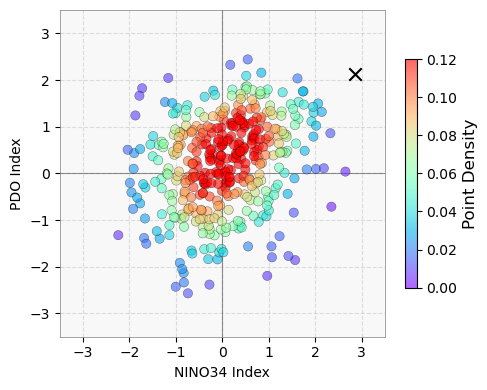

In [93]:
x_clean = np.array(lens_mean_nino34_blob_analogs)
y_clean = np.array(lens_mean_pdo_blob_analogs)

mask = np.isfinite(x_clean) & np.isfinite(y_clean)
x_clean = x_clean[mask]
y_clean = y_clean[mask]

plt.figure(figsize=(5, 4))

if len(x_clean) > 0:
    xy = np.vstack([x_clean, y_clean])
    try:
        kde = gaussian_kde(xy)
        density = kde(xy)
        sc = plt.scatter(x_clean, y_clean, 
                        c=density, cmap='rainbow', alpha=0.6,
                        edgecolor='k', linewidth=0.3, vmin=0, vmax=0.12,
                        s=45, zorder=3)
        cbar = plt.colorbar(sc, shrink=0.7)
        cbar.set_label('Point Density', fontsize=12)
    except:
        sc = plt.scatter(x_clean, y_clean, 
                        c='tab:blue', alpha=0.6,
                        edgecolor='k', linewidth=0.3,
                        s=45, zorder=3)
else:
    print("No valid data points remaining after NaN/inf removal")

if np.isfinite(2.85) and np.isfinite(2.13):
    plt.scatter(2.85, 2.13, c='k', s=80, marker='x', zorder=4)
plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4, zorder=2)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.4, zorder=2)
plt.xlabel('NINO34 Index', fontsize=10)
plt.ylabel('PDO Index', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4, zorder=1)
plt.gca().set_facecolor('#f8f8f8')
for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('gray')
    spine.set_linewidth(0.5)
plt.ylim(-3.5, 3.5)
plt.xlim(-3.5, 3.5)
plt.tight_layout()
plt.show()

In [94]:
df = pd.DataFrame({
    'Mean PDO Index': y_clean,
    'Mean Nino 3.4 Index': x_clean,
}).dropna()

4.77% of data exceeds 1.7115485472132739


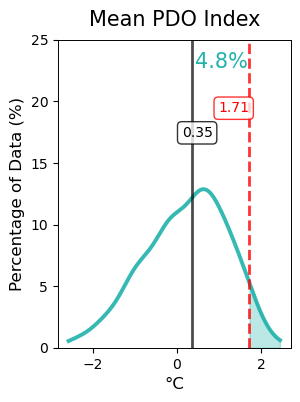

In [96]:
# Your data and threshold
column_name = 'Mean PDO Index'#'Max. PDO Index'
threshold = 1.7115485472132739#2.130971661216526
color = 'lightseagreen'

pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# --- KDE ---
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100

plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)

mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='red', linestyle='dashed', lw=2.0, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='k', linestyle='-', lw=2, alpha=0.7)

# --- Annotate the threshold ---
plt.text(threshold, plt.ylim()[1]+6.5, 
         f'{threshold:.2f}', 
         ha='right', 
         va='top', fontsize=10, c='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

# --- Annotate the threshold ---
plt.text(median+0.5, plt.ylim()[1]+4.5, 
         f'{median:.2f}', 
         ha='right', 
         va='top', fontsize=10, color='k',
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1]-1, plt.ylim()[1]+10.5, 
         '4.8%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen', zorder=20)

# --- Styling ---
plt.title(f'{column_name}', fontsize=15, pad=10)
plt.xlabel('°C', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()

13.07% of data exceeds 1.113568136446258


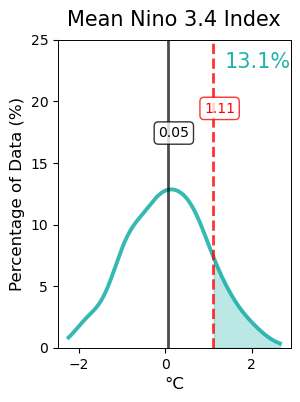

In [107]:
# Your data and threshold
column_name = 'Mean Nino 3.4 Index'# 'Max. Nino 3.4 Index'
threshold = 1.113568136446258# 2.8640999606960413
color = 'lightseagreen'

# # Your data and threshold
# column_name = 'Max. PDO Index'
# threshold = 2.130971661216526
# color = 'lightseagreen'

pct_above = (df[column_name] > threshold).mean() * 100  # % of data > threshold
print(f"{pct_above:.2f}% of data exceeds {threshold}")  # For debugging

# --- Plot setup ---
plt.figure(figsize=(3, 4))
counts, bin_edges = np.histogram(df[column_name], bins=15)
bin_percentages = (counts / len(df[column_name])) * 100
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# --- KDE ---
kde = gaussian_kde(df[column_name])
x = np.linspace(df[column_name].min(), df[column_name].max(), 500)
y_kde = kde(x) * bin_width * 100

plt.plot(x, y_kde, color=color, linewidth=2.8, alpha=0.9)

mask = x >= threshold
plt.fill_between(x[mask], y_kde[mask], color='lightseagreen', alpha=0.3, label=f'Top {pct_above:.1f}%')

# --- Threshold & Median Lines ---
plt.axvline(threshold, color='red', linestyle='dashed', lw=2.0, alpha=0.8)
median = np.median(df[column_name])
plt.axvline(median, color='k', linestyle='-', lw=2, alpha=0.7)

# --- Annotate the threshold ---
plt.text(threshold+0.5, plt.ylim()[1]+6.5, 
         f'{threshold:.2f}', 
         ha='right', 
         va='top', fontsize=10, c='red',
         bbox=dict(facecolor='white', edgecolor='red', boxstyle='round,pad=0.3', alpha=0.8))

# --- Annotate the threshold ---
plt.text(median+0.5, plt.ylim()[1]+4.5, 
         f'{median:.2f}', 
         ha='right', 
         va='top', fontsize=10, color='k',
         bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3', alpha=0.8))

plt.text(plt.xlim()[1]+0.01, plt.ylim()[1]+10.5, 
         '13.1%', 
         ha='right', 
         va='top', fontsize=15, c='lightseagreen', zorder=20)

# --- Styling ---
plt.title(f'{column_name}', fontsize=15, pad=10)
plt.xlabel('°C', fontsize=12)
plt.ylabel('Percentage of Data (%)', fontsize=12)
plt.ylim(0, 25)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().set_facecolor('white')
# plt.legend(loc='upper right')

for spine in plt.gca().spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('k')
    spine.set_linewidth(0.7)

plt.show()